In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

import pickle
import warnings

warnings.filterwarnings('ignore')

In [3]:
#Load Dataset
# Loading California Housing Dataset

housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df['HousePrice'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
#Check Missing Values
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

In [6]:
#Statistical Summary
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


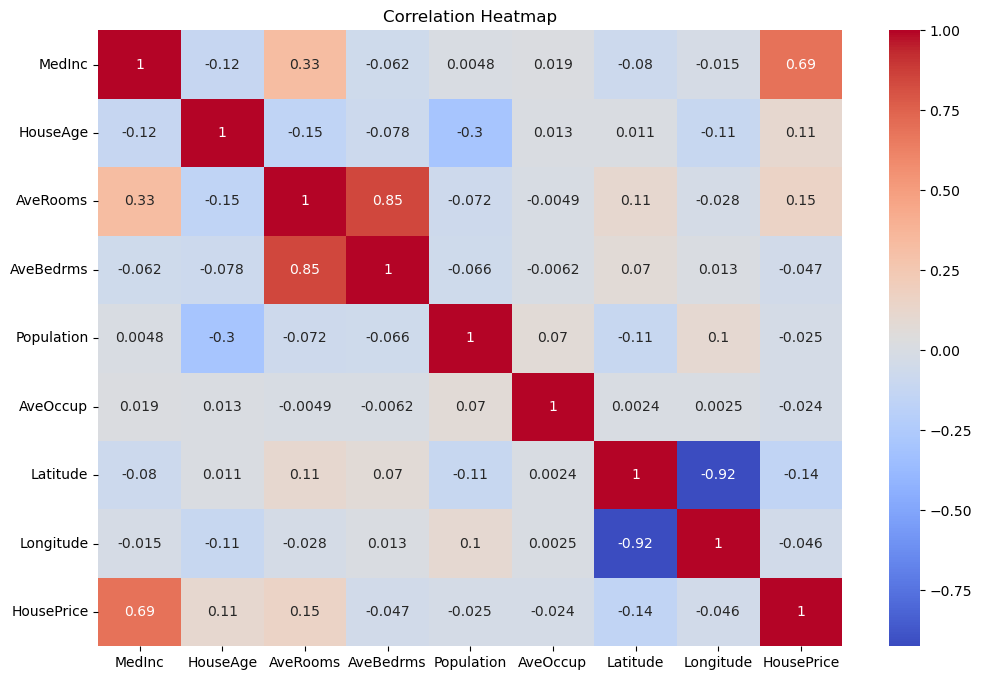

In [7]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

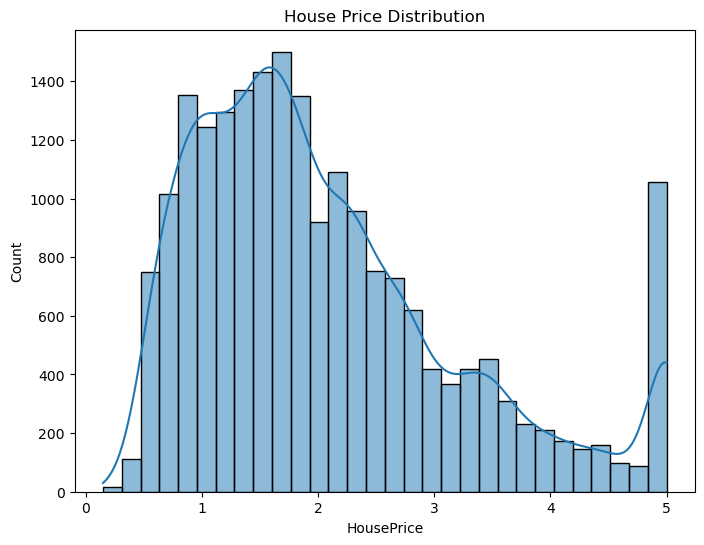

In [8]:
#House Price Distribution
plt.figure(figsize=(8,6))

sns.histplot(
    df['HousePrice'],
    bins=30,
    kde=True
)

plt.title("House Price Distribution")

plt.show()

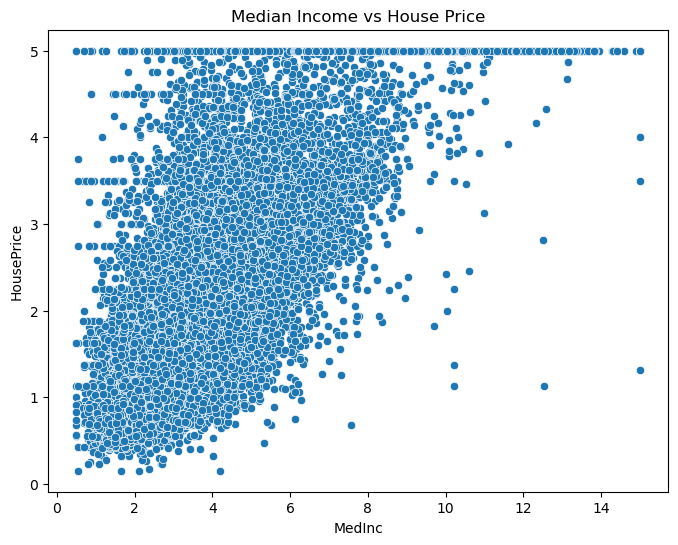

In [9]:
#Median Income vs House Price
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['MedInc'],
    y=df['HousePrice']
)

plt.title("Median Income vs House Price")

plt.show()

In [10]:
#Feature Selection
X = df.drop(
    'HousePrice',
    axis=1
)

y = df['HousePrice']

In [11]:
#Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Applied Successfully")

Feature Scaling Applied Successfully


In [12]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (16512, 8)
Testing Shape: (4128, 8)


In [13]:
#Train Multiple Models
models = {

    "Linear Regression":
    LinearRegression(),

    "Ridge Regression":
    Ridge(alpha=1.0),

    "Decision Tree":
    DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

In [14]:
#Model Evaluation
results = {}

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results[name] = {

        "RMSE": rmse,

        "R2 Score": r2
    }

print("Models Evaluated Successfully")

Models Evaluated Successfully


In [15]:
#Performance Comparison Table
results_df = pd.DataFrame(
    results
).T

results_df = results_df.sort_values(
    by='R2 Score',
    ascending=False
)

results_df

,RMSE,R2 Score
Decision Tree,0.724234,0.599732
Ridge Regression,0.745554,0.575819
Linear Regression,0.745581,0.575788


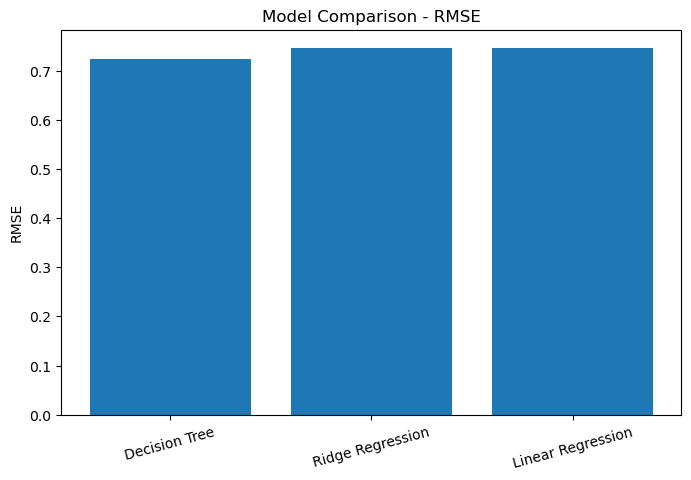

In [16]:
#RMSE Comparison Chart
plt.figure(figsize=(8,5))

plt.bar(
    results_df.index,
    results_df['RMSE']
)

plt.title(
    "Model Comparison - RMSE"
)

plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.show()

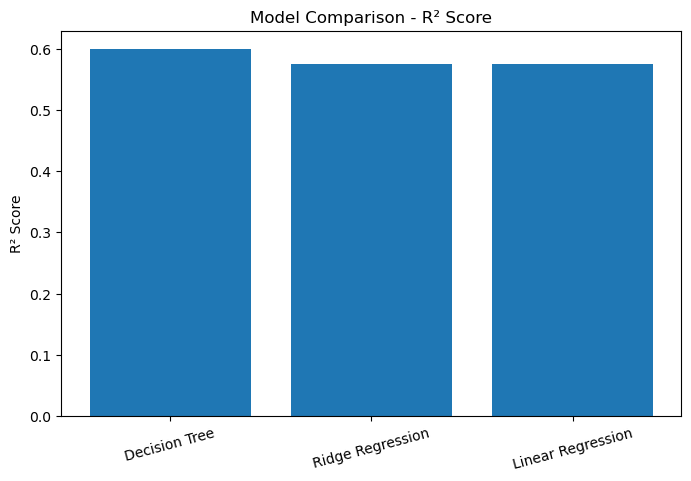

In [17]:
#R² Score Comparison Chart
plt.figure(figsize=(8,5))

plt.bar(
    results_df.index,
    results_df['R2 Score']
)

plt.title(
    "Model Comparison - R² Score"
)

plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.show()

In [18]:
#Performance Insights
print("Model Performance Summary")

print("-"*50)

for model in results_df.index:

    print(
        f"{model}: "
        f"RMSE = {results_df.loc[model,'RMSE']:.4f}, "
        f"R² = {results_df.loc[model,'R2 Score']:.4f}"
    )

Model Performance Summary
--------------------------------------------------
Decision Tree: RMSE = 0.7242, R² = 0.5997
Ridge Regression: RMSE = 0.7456, R² = 0.5758
Linear Regression: RMSE = 0.7456, R² = 0.5758


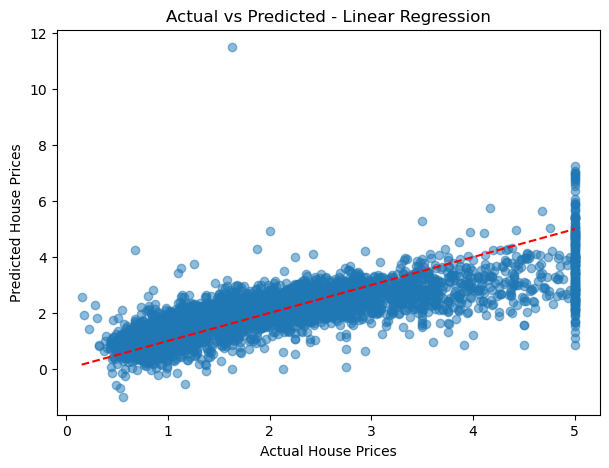

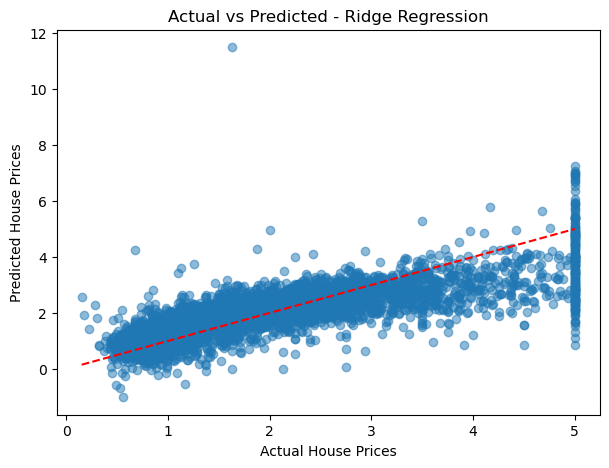

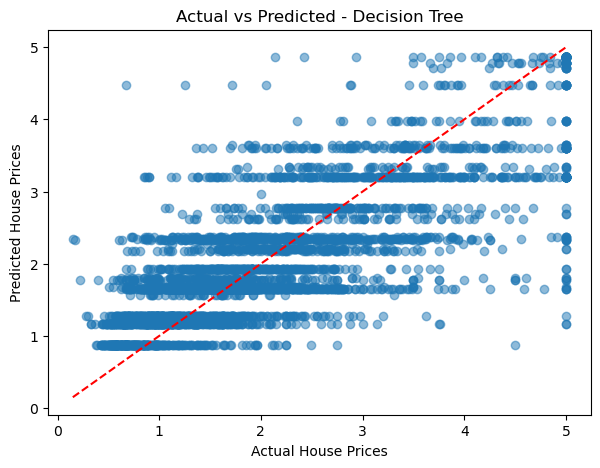

In [19]:
# Actual vs Predicted for all models

for name, model in models.items():

    y_pred = model.predict(X_test)

    plt.figure(figsize=(7,5))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.5
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--'
    )

    plt.xlabel("Actual House Prices")
    plt.ylabel("Predicted House Prices")

    plt.title(f"Actual vs Predicted - {name}")

    plt.show()

In [20]:
#Best Performing Model
best_model_name = results_df.index[0]

print(
    "Best Performing Model:",
    best_model_name
)

Best Performing Model: Decision Tree


In [21]:
#Train Best Model Again
best_model = models[
    best_model_name
]

best_model.fit(
    X_train,
    y_train
)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


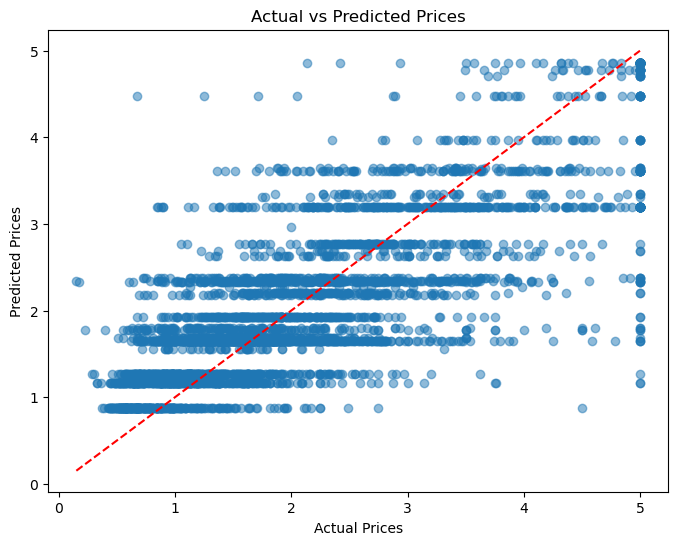

In [22]:
#Actual vs Predicted Plot
y_pred = best_model.predict(
    X_test
)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel(
    "Actual Prices"
)

plt.ylabel(
    "Predicted Prices"
)

plt.title(
    "Actual vs Predicted Prices"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

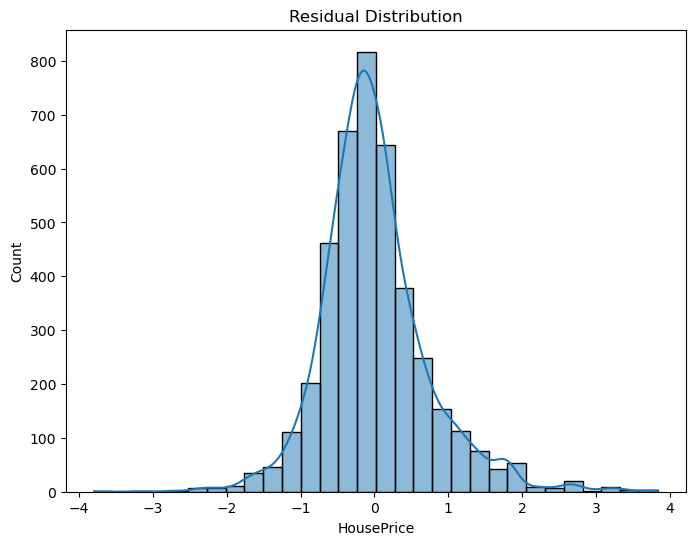

In [23]:
#Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

In [24]:
#Feature Importance (Decision Tree)
tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

importance = pd.DataFrame({

    'Feature':
    X.columns,

    'Importance':
    tree_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,MedInc,0.771212
5,AveOccup,0.128407
1,HouseAge,0.041621
2,AveRooms,0.031261
6,Latitude,0.022049
4,Population,0.002485
7,Longitude,0.002097
3,AveBedrms,0.000869


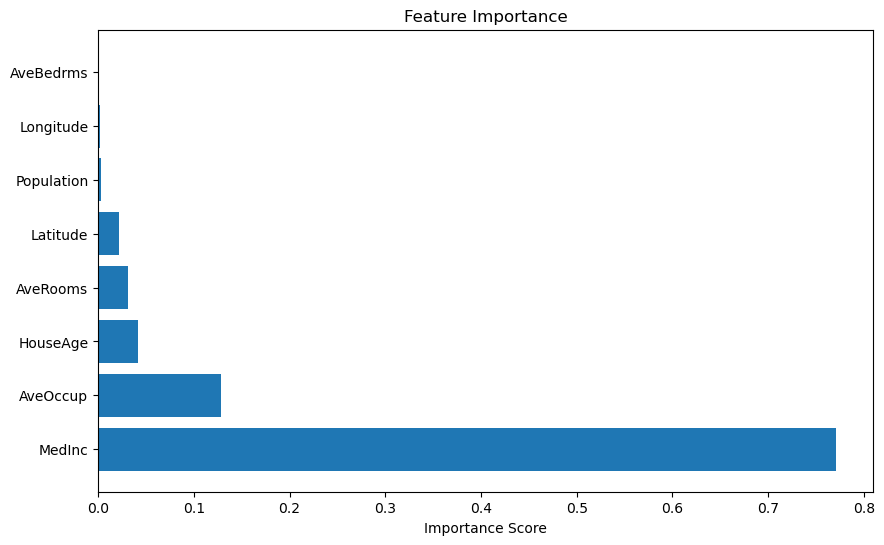

In [25]:
#Feature Importance Graph
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title(
    "Feature Importance"
)

plt.xlabel(
    "Importance Score"
)

plt.show()

In [26]:
#Sample Prediction
sample_data = X_test[0].reshape(
    1,
    -1
)

prediction = best_model.predict(
    sample_data
)

print(
    "Predicted Price:",
    prediction[0]
)

Predicted Price: 1.168572668112798


In [27]:
#Save Best Model
with open(
    'best_performing_model.pkl',
    'wb'
) as file:

    pickle.dump(
        best_model,
        file
    )

print(
    "Best Model Saved Successfully"
)

Best Model Saved Successfully
